# Product Category Classification - Amazon Sales Dataset

## Objective
Build a multiclass classification model to predict the **product category** of an order based on its numerical features.

## Target variable
- `product_category`: one of 6 categories — Books, Electronics, Fashion, Beauty, Sports, Home & Kitchen

## Features used
- `price`: original product price
- `discount_percent`: discount percentage applied
- `quantity_sold`: quantity sold
- `rating`: product rating
- `review_count`: number of reviews

## Algorithm
RandomForestClassifier — an ensemble of decision trees that votes on the final prediction.

## Important note
This is a challenging classification problem. The numerical features available (price, discount, rating, etc.) do not strongly distinguish between categories — a book and a beauty product can have the same price and rating. Therefore, the model accuracy is expected to be modest, which is an honest reflection of the data limitations.

## 1. Imports and data loading

Loading all necessary libraries and the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## 2. Statistical summary

Descriptive statistics for numeric columns to understand the scale and distribution of each feature.

In [2]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


## 3. Data cleaning

Filling missing values with 0 to ensure the model does not receive null data.

In [3]:
df = df.fillna(0)
print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


## 4. Target variable distribution

Checking how many orders exist per product category. A balanced distribution means the model will not be biased toward the most frequent category.

product_category
Beauty            8465
Fashion           8365
Books             8327
Electronics       8320
Sports            8265
Home & Kitchen    8258
Name: count, dtype: int64


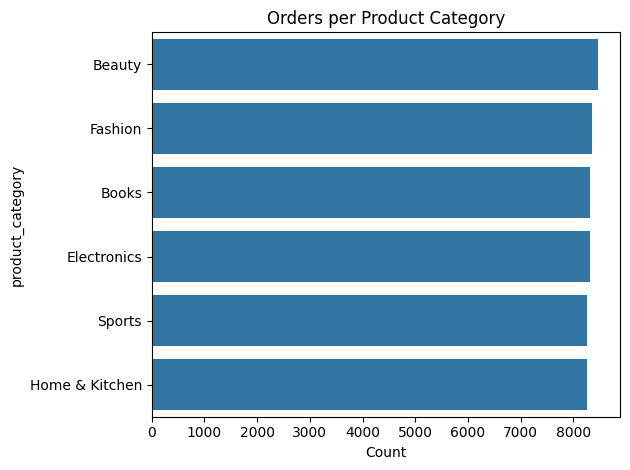

In [4]:
print(df["product_category"].value_counts())

sns.countplot(y="product_category", data=df, order=df["product_category"].value_counts().index)
plt.title("Orders per Product Category")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## 5. Feature distribution by category

Visualizing whether price differs across categories. If the distributions overlap significantly, it indicates that price alone cannot distinguish between categories — which will limit model accuracy.

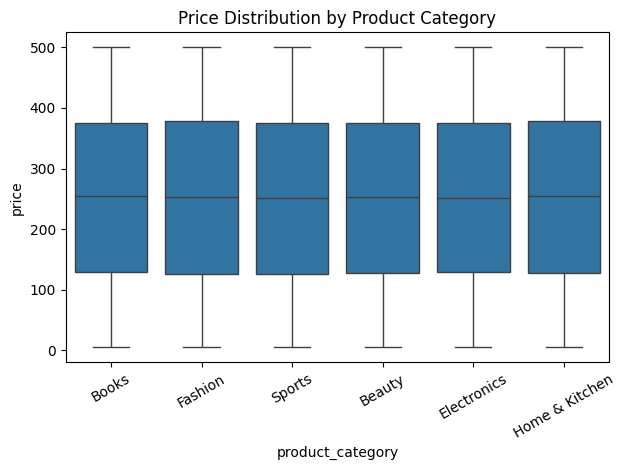

In [5]:
sns.boxplot(x="product_category", y="price", data=df)
plt.title("Price Distribution by Product Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Feature and target definition

Selecting numerical features as input and `product_category` as the target variable.

In [6]:
X = df[["price", "discount_percent", "quantity_sold", "rating", "review_count"]]
y = df["product_category"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nCategories:", y.unique())

Features shape: (50000, 5)
Target shape: (50000,)

Categories: ['Books' 'Fashion' 'Sports' 'Beauty' 'Electronics' 'Home & Kitchen']


## 7. Train/test split

Splitting the data into 80% for training and 20% for testing. `stratify=y` ensures each category has the same proportion in both sets.

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", x_train.shape)
print("Test: ", x_test.shape)

Train: (40000, 5)
Test:  (10000, 5)


## 8. Model training

Training a `RandomForestClassifier` with 100 decision trees. Each tree votes on the predicted category, and the majority vote wins.

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

## 9. Prediction

In [9]:
pred = model.predict(x_test)

## 10. Model evaluation

For multiclass classification, we look at:
- **Accuracy:** overall percentage of correct predictions
- **Classification report:** precision, recall and F1-score per category

Since there are 6 categories and the features do not strongly differentiate them, a random baseline would score around 16.7% (1/6). Any result above that indicates the model learned something from the data.

In [10]:
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred))

Accuracy: 0.1613

Classification Report:
                precision    recall  f1-score   support

        Beauty       0.15      0.17      0.16      1693
         Books       0.15      0.16      0.15      1665
   Electronics       0.17      0.17      0.17      1664
       Fashion       0.18      0.17      0.18      1673
Home & Kitchen       0.16      0.15      0.15      1652
        Sports       0.15      0.15      0.15      1653

      accuracy                           0.16     10000
     macro avg       0.16      0.16      0.16     10000
  weighted avg       0.16      0.16      0.16     10000



## 11. Confusion matrix

Each row represents the actual category, and each column represents the predicted category. The diagonal shows correct predictions. Off-diagonal values show where the model confused one category for another.

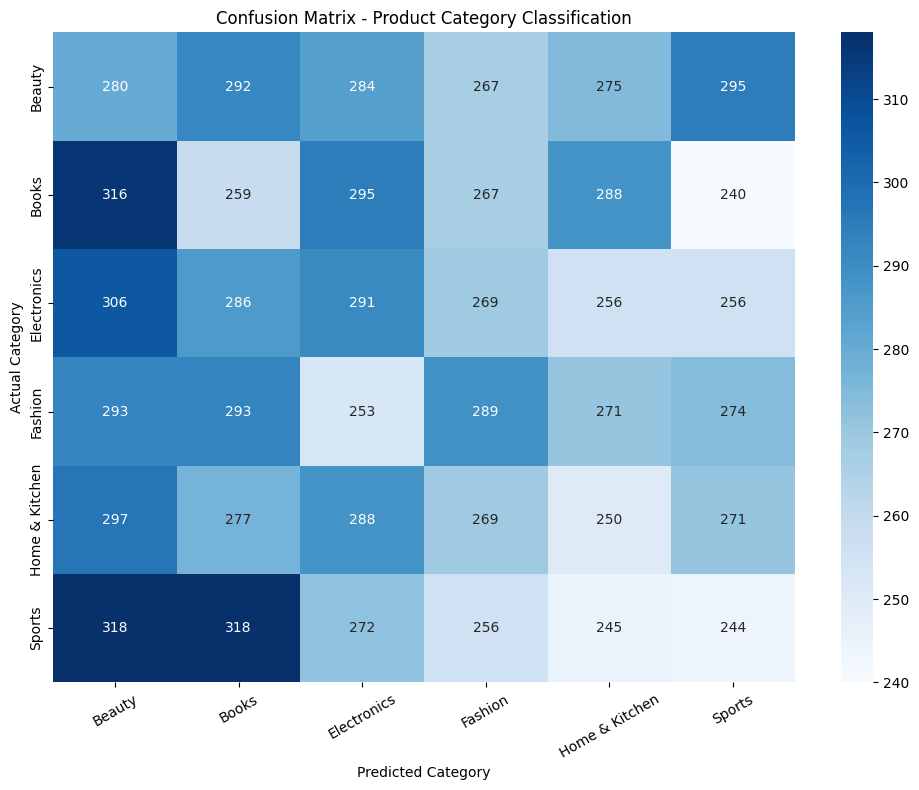

In [11]:
cm = confusion_matrix(y_test, pred, labels=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix - Product Category Classification")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 12. Feature importance

Which features the model considered most relevant for predicting product category.

price               0.345476
review_count        0.317317
rating              0.188036
quantity_sold       0.077284
discount_percent    0.071888
dtype: float64


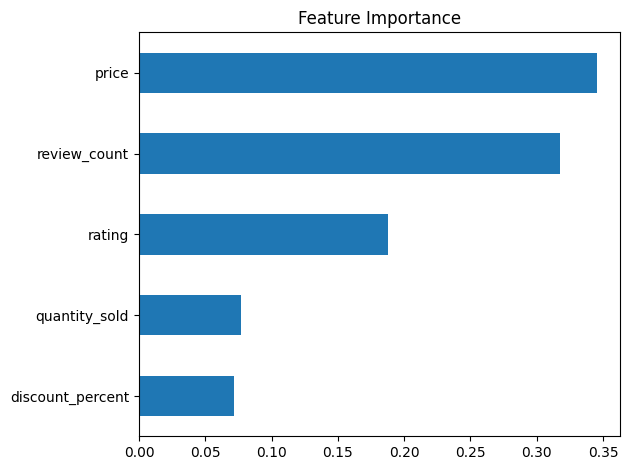

In [12]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Conclusions

- The model was trained to classify orders into 6 product categories using only numerical features.
- The accuracy is modest because numerical features like price, discount and rating do not strongly distinguish between categories — a book and a beauty product can have identical values for all features.
- The confusion matrix reveals which categories are most frequently confused with each other.
- A more accurate solution would require text-based features such as product descriptions, which would allow NLP techniques to differentiate categories more effectively.